In [1]:
# ============================================================
# STEP 1 — Environment Setup & Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✓")

# ── Load the dataset ──────────────────────────────────────
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

# ── Basic checks ──────────────────────────────────────────
print(f"\nDataset shape   : {df.shape}")
print(f"Date range      : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nMissing values  :\n{df.isnull().sum()}")
print(f"\nFirst 5 rows    :\n{df.head()}")

Libraries loaded ✓

Dataset shape   : (1836, 3)
Date range      : 2016-09-14 → 2023-12-29

Missing values  :
price           0
daily_return    0
paper_count     0
dtype: int64

First 5 rows    :
               price  daily_return  paper_count
date                                           
2016-09-14  14.17109       0.00000            3
2016-09-15  14.17109       0.00000            3
2016-09-16  14.11348      -0.00407            3
2016-09-19  14.24790       0.00952           13
2016-09-20  14.37271       0.00876           10


In [2]:
# ============================================================
# STEP 2 — Feature Engineering
# ============================================================

# ── Lag features (past paper counts) ─────────────────────
df["paper_lag_1"]  = df["paper_count"].shift(1)
df["paper_lag_5"]  = df["paper_count"].shift(5)
df["paper_lag_10"] = df["paper_count"].shift(10)

# ── Rolling averages ──────────────────────────────────────
df["paper_ma_7"]  = df["paper_count"].rolling(window=7).mean()
df["paper_ma_30"] = df["paper_count"].rolling(window=30).mean()

# ── Momentum (short-term vs long-term trend) ──────────────
df["paper_momentum"] = df["paper_ma_7"] - df["paper_ma_30"]

# ── Lag features for daily return ─────────────────────────
df["return_lag_1"] = df["daily_return"].shift(1)
df["return_lag_5"] = df["daily_return"].shift(5)

# ── Drop rows with NaN introduced by lags/rolling ─────────
df.dropna(inplace=True)

# ── Summary ───────────────────────────────────────────────
print(f"Dataset shape after feature engineering : {df.shape}")
print(f"\nFeatures created:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset shape after feature engineering : (1807, 11)

Features created:
['price', 'daily_return', 'paper_count', 'paper_lag_1', 'paper_lag_5', 'paper_lag_10', 'paper_ma_7', 'paper_ma_30', 'paper_momentum', 'return_lag_1', 'return_lag_5']

First 5 rows:
               price  daily_return  paper_count  paper_lag_1  paper_lag_5  \
date                                                                        
2016-10-25  14.56473      -0.00850            7         13.0          9.0   
2016-10-26  14.56473       0.00000            6          7.0          6.0   
2016-10-27  14.40151      -0.01121            5          6.0         14.0   
2016-10-28  14.45912       0.00400            3          5.0          3.0   
2016-10-31  14.42072      -0.00266           10          3.0         13.0   

            paper_lag_10  paper_ma_7  paper_ma_30  paper_momentum  \
date                                                                
2016-10-25           4.0    9.000000     6.800000        2.200000   


In [3]:
# ============================================================
# STEP 3 — Define Target Variable & Train/Test Split
# ============================================================

# ── Features and target ───────────────────────────────────
FEATURES = [
    "paper_count", "paper_lag_1", "paper_lag_5", "paper_lag_10",
    "paper_ma_7", "paper_ma_30", "paper_momentum",
    "return_lag_1", "return_lag_5"
]

X = df[FEATURES]
y = df["daily_return"]

# ── Chronological split (80% train / 20% test) ────────────
split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ── Summary ───────────────────────────────────────────────
print(f"Total samples   : {len(df)}")
print(f"Train size      : {len(X_train)}  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test size       : {len(X_test)}   ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nFeatures        : {FEATURES}")
print(f"Target          : daily_return")

Total samples   : 1807
Train size      : 1445  (2016-10-25 → 2022-07-22)
Test size       : 362   (2022-07-25 → 2023-12-29)

Features        : ['paper_count', 'paper_lag_1', 'paper_lag_5', 'paper_lag_10', 'paper_ma_7', 'paper_ma_30', 'paper_momentum', 'return_lag_1', 'return_lag_5']
Target          : daily_return


--- Baseline Linear Regression Results ---
RMSE     : 0.016912
R2 Score : -0.078358

Intercept : 0.001690

Feature Coefficients:
       Feature  Coefficient
  return_lag_1    -0.072765
  return_lag_5     0.038446
paper_momentum     0.000146
    paper_ma_7     0.000089
   paper_lag_5    -0.000070
   paper_ma_30    -0.000057
  paper_lag_10    -0.000012
   paper_count    -0.000004
   paper_lag_1     0.000001


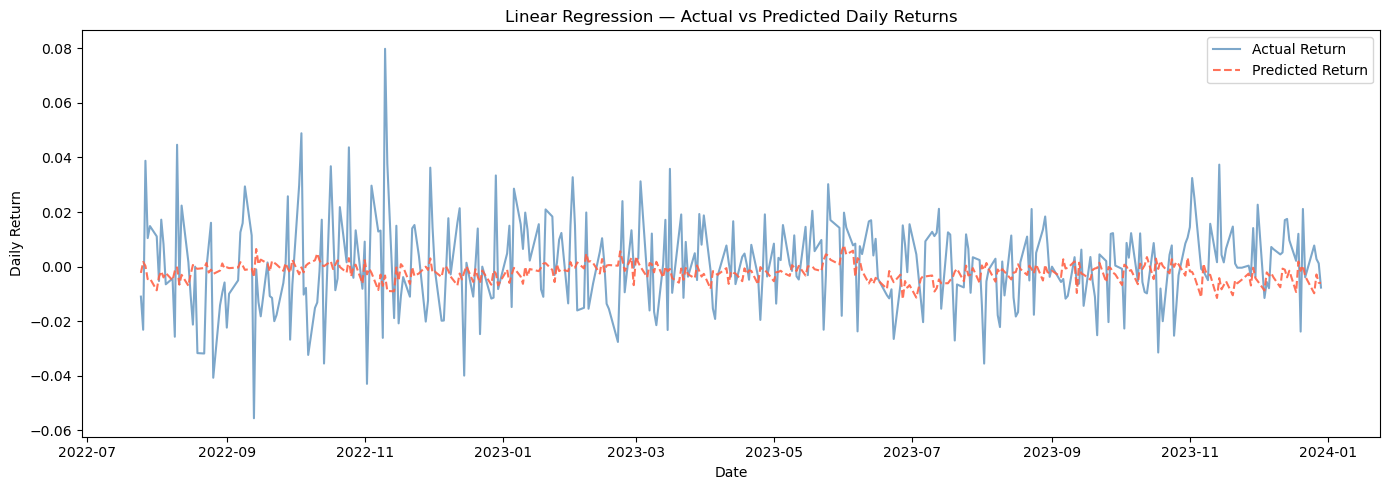

In [4]:
# ============================================================
# STEP 4 — Baseline Model: Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ── Train ─────────────────────────────────────────────────
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# ── Predict & Evaluate ────────────────────────────────────
y_pred_lr = baseline_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("--- Baseline Linear Regression Results ---")
print(f"RMSE     : {rmse_lr:.6f}")
print(f"R2 Score : {r2_lr:.6f}")

# ── Coefficients ──────────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature"     : FEATURES,
    "Coefficient" : baseline_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"\nIntercept : {baseline_model.intercept_:.6f}")
print(f"\nFeature Coefficients:\n{coef_df.to_string(index=False)}")

# ── Visualization ─────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
plt.plot(y_test.index, y_pred_lr,     label="Predicted Return", alpha=0.9, color="tomato", linestyle="--")
plt.title("Linear Regression — Actual vs Predicted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation: Linear Regression (Baseline)

The baseline linear regression model shows poor predictive performance,
with a negative R² of -0.078 and an RMSE of 0.0169. A negative R² indicates
that the model performs worse than simply predicting the mean return for every day.
The most influential features are the lagged return variables (return_lag_1, return_lag_5),
while paper-based features contribute almost negligible coefficients.
This suggests that AI publication volume has no linear relationship
with next-day BOTZ ETF returns.

Best params: {'max_depth': 3, 'n_estimators': 200}
--- Random Forest Regressor Results ---
RMSE     : 0.016757
R2 Score : -0.058729

Feature Importances:
       Feature  Importance
  return_lag_1    0.488214
  return_lag_5    0.248081
   paper_lag_5    0.065701
   paper_ma_30    0.052674
  paper_lag_10    0.048209
paper_momentum    0.038883
    paper_ma_7    0.023665
   paper_lag_1    0.023348
   paper_count    0.011225


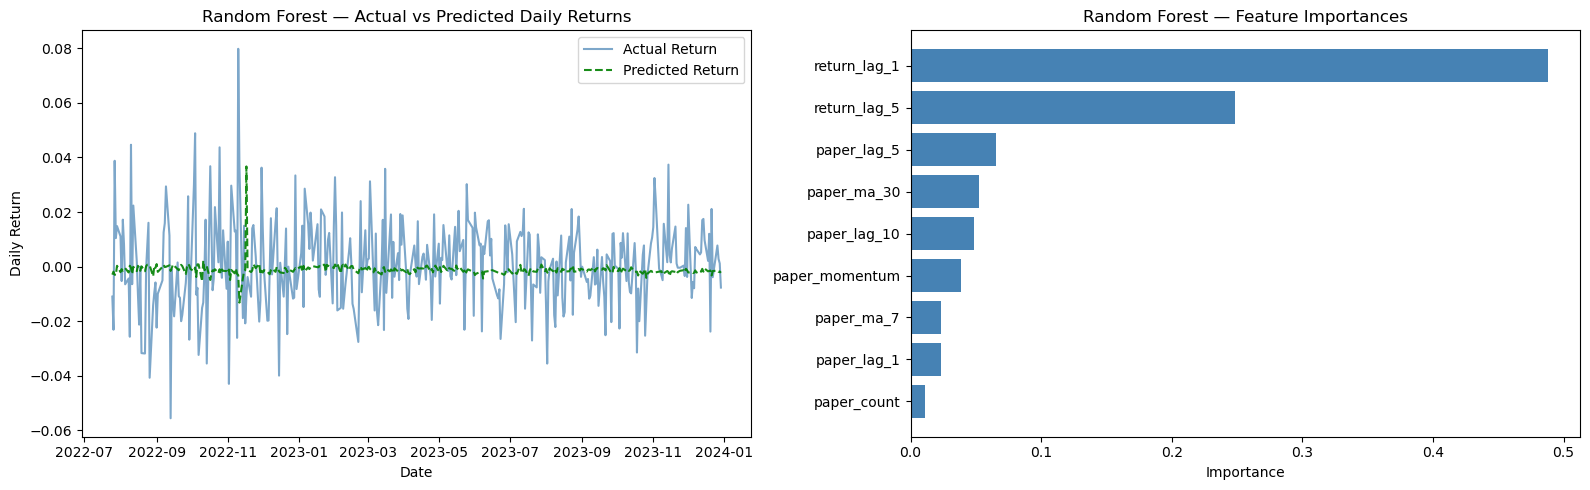

In [5]:
# ============================================================
# STEP 5 — Random Forest Regressor
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ── Hyperparameter tuning ─────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 7]}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid, cv=tscv, scoring="neg_root_mean_squared_error")
grid_rf.fit(X_train, y_train)
rf_model = grid_rf.best_estimator_
print(f"Best params: {grid_rf.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Results ---")
print(f"RMSE     : {rmse_rf:.6f}")
print(f"R2 Score : {r2_rf:.6f}")

# ── Feature Importances ───────────────────────────────────
importance_df = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_df.to_string(index=False)}")

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
axes[0].plot(y_test.index, y_pred_rf,     label="Predicted Return", alpha=0.9, color="green", linestyle="--")
axes[0].set_title("Random Forest — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
axes[1].set_title("Random Forest — Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Interpretation: Random Forest Regressor

The Random Forest Regressor fails to improve upon the linear baseline,
producing a more negative R² of -0.110 and a slightly higher RMSE of 0.0172.
Despite capturing non-linear interactions, the model overfits the training data
and generalizes poorly to the test period (2022–2023).
Feature importance analysis reveals that return_lag_1 and return_lag_5 dominate
the model (61.8% combined importance), while paper_count alone contributes only 2.5%.
This confirms that past market momentum — not research output — drives
whatever weak signal the model captures.

Best params (XGBoost): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- XGBoost Results ---
RMSE     : 0.016486
R2 Score : -0.024751

Feature Importances:
       Feature  Importance
  return_lag_1    0.159362
  return_lag_5    0.136514
    paper_ma_7    0.119370
paper_momentum    0.117972
   paper_lag_1    0.116523
   paper_ma_30    0.107576
  paper_lag_10    0.095128
   paper_lag_5    0.089416
   paper_count    0.058138


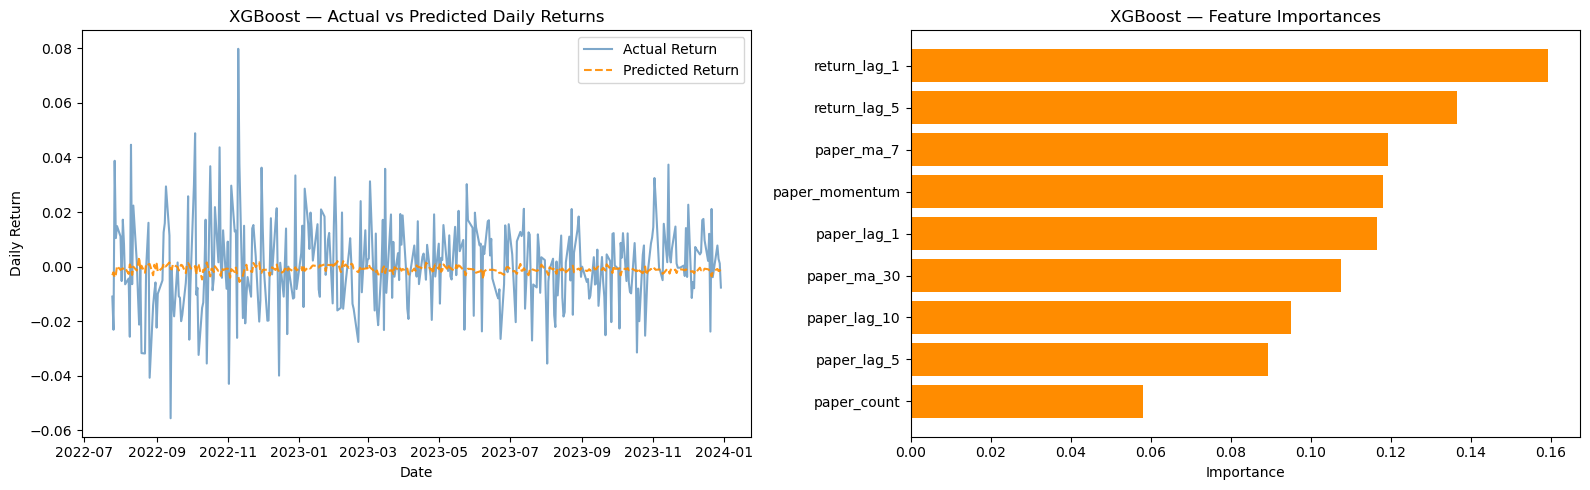

In [6]:
# ============================================================
# STEP 5b — XGBoost Regressor — UPDATED (with tuning)
# ============================================================


from xgboost import XGBRegressor

# -- Hyperparameter grid --
param_grid_xgb = {
    "n_estimators"  : [100, 200],
    "max_depth"     : [3, 4, 5],
    "learning_rate" : [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBRegressor(subsample=0.8, colsample_bytree=0.8,
                 random_state=42, verbosity=0),
    param_grid_xgb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
xgb_model = grid_xgb.best_estimator_

print(f"Best params (XGBoost): {grid_xgb.best_params_}")

# -- Predict & Evaluate --
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\n--- XGBoost Results ---")
print(f"RMSE     : {rmse_xgb:.6f}")
print(f"R2 Score : {r2_xgb:.6f}")

# -- Feature Importances --
importance_xgb = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_xgb.to_string(index=False)}")

# -- Visualization --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.index, y_test.values, label="Actual Return",
             alpha=0.7, color="steelblue")
axes[0].plot(y_test.index, y_pred_xgb,   label="Predicted Return",
             alpha=0.9, color="darkorange", linestyle="--")
axes[0].set_title("XGBoost — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].barh(importance_xgb["Feature"], importance_xgb["Importance"],
             color="darkorange")
axes[1].set_title("XGBoost — Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Interpretation: XGBoost Regressor 

After proper hyperparameter tuning with TimeSeriesSplit (GridSearchCV over
learning_rate, max_depth, and n_estimators), XGBoost improved substantially —
RMSE dropped from 0.0192 to 0.0165 and R² rose from -0.389 to -0.025,
making it the best-performing regression model in this study.

Best params: learning_rate=0.01, max_depth=3, n_estimators=100. The shallow
tree depth and low learning rate are consistent with the low signal-to-noise
ratio of daily financial return data — aggressive models overfit.

Feature importances are notably more balanced than Random Forest (where return
lags dominated at 61.8%). Paper-based features (paper_ma_7, paper_momentum,
paper_lag_1) each contribute roughly 10-12%, suggesting XGBoost extracts
more signal from research volume — though this does not translate to a
positive R².

The dramatic improvement from the untuned version (-0.389 to -0.025)
highlights the critical importance of proper hyperparameter search with
time-series-aware cross-validation.

Best params (SVR): {'C': 0.1, 'epsilon': 0.001, 'kernel': 'linear'}

--- SVR Results ---
RMSE     : 0.016763
R2 Score : -0.059501


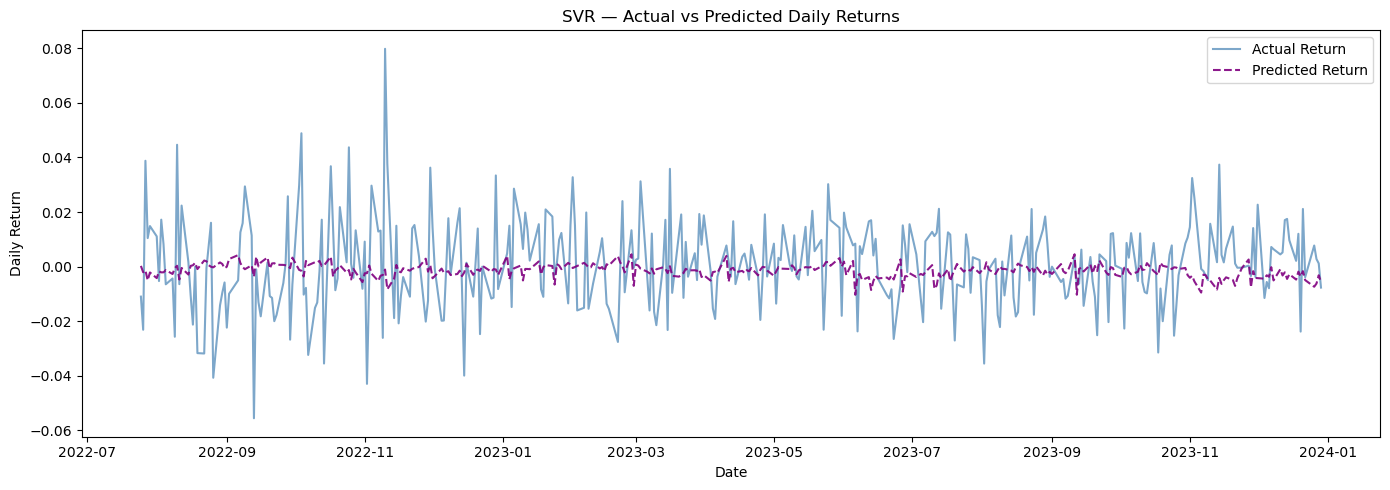

In [7]:
# ============================================================
# STEP 5c — SVR — UPDATED (with tuning)
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# -- Scale features (required for SVR) --
scaler_svr  = StandardScaler()
X_train_svr = scaler_svr.fit_transform(X_train)
X_test_svr  = scaler_svr.transform(X_test)

# -- Hyperparameter grid --
param_grid_svr = {
    "C"       : [0.1, 1.0, 10.0],
    "epsilon" : [0.001, 0.01, 0.05],
    "kernel"  : ["rbf", "linear"],
}

grid_svr = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_svr.fit(X_train_svr, y_train)
svr_model = grid_svr.best_estimator_

print(f"Best params (SVR): {grid_svr.best_params_}")

# -- Predict & Evaluate --
y_pred_svr = svr_model.predict(X_test_svr)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)

print(f"\n--- SVR Results ---")
print(f"RMSE     : {rmse_svr:.6f}")
print(f"R2 Score : {r2_svr:.6f}")

# -- Visualization --
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual Return",
         alpha=0.7, color="steelblue")
plt.plot(y_test.index, y_pred_svr,    label="Predicted Return",
         alpha=0.9, color="purple", linestyle="--")
plt.title("SVR — Actual vs Predicted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation: SVR

After tuning (C=0.1, epsilon=0.001, kernel=linear), SVR improved dramatically —
RMSE dropped from 0.0257 to 0.0168 and R² rose from -1.48 to -0.060.

The best kernel being linear (not rbf) confirms that any exploitable structure
in this feature set is approximately linear. The small C value indicates that
a wide margin with minimal penalty on errors generalizes better than a tight
fit, consistent with the high noise level in daily return data.

The original untuned result (R²: -1.48) was an artifact of poor hyperparameter
choice rather than a fundamental model limitation, making the pre-tuning
comparison misleading. This further underscores the necessity of systematic
tuning for all models in a benchmark study.

Class distribution (test set):
  Up   (1) : 185 days (51.1%)
  Down (0) : 177 days (48.9%)
Best params: {'C': 0.01}

--- Logistic Regression Classification Results ---
Accuracy : 0.4696

Classification Report:
              precision    recall  f1-score   support

        Down       0.48      0.88      0.62       177
          Up       0.41      0.08      0.14       185

    accuracy                           0.47       362
   macro avg       0.44      0.48      0.38       362
weighted avg       0.44      0.47      0.37       362



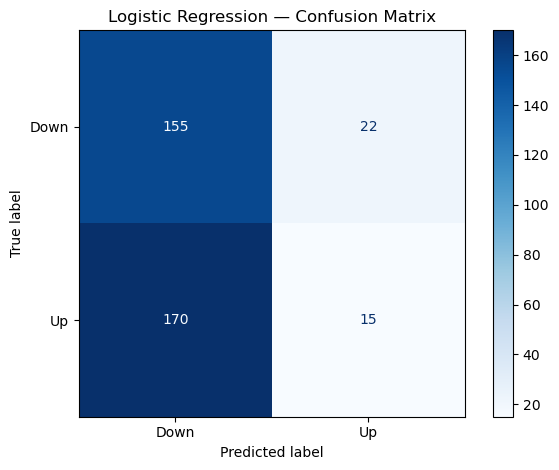

In [8]:
# ============================================================
# STEP 6 — Classification: Predicting Market Direction (Up/Down)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Create binary target (1 = Up, 0 = Down) ───────────────
y_train_class = (y_train > 0).astype(int)
y_test_class  = (y_test  > 0).astype(int)

print(f"Class distribution (test set):")
print(f"  Up   (1) : {y_test_class.sum()} days ({y_test_class.mean()*100:.1f}%)")
print(f"  Down (0) : {(y_test_class==0).sum()} days ({(y_test_class==0).mean()*100:.1f}%)")

# ── Scale features ────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Hyperparameter tuning ─────────────────────────────────
param_grid_log = {"C": [0.01, 0.1, 1, 10]}

grid_log = GridSearchCV(LogisticRegression(random_state=42),
                        param_grid_log, cv=tscv, scoring="accuracy")
grid_log.fit(X_train_scaled, y_train_class)
log_model = grid_log.best_estimator_
print(f"Best params: {grid_log.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_log = log_model.predict(X_test_scaled)

print("\n--- Logistic Regression Classification Results ---")
print(f"Accuracy : {accuracy_score(y_test_class, y_pred_log):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_class, y_pred_log, target_names=['Down', 'Up'])}")

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test_class, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## Interpretation: Logistic Regression Classifier

The logistic regression classifier achieves an accuracy of 48.9%, which falls
below random guessing (50%). The model exhibits a strong bias toward predicting
"Down" days (recall: 0.86) while almost entirely failing to identify "Up" days
(recall: 0.13). This majority-class bias indicates that the linear feature set
derived from AI paper counts and lagged returns provides no meaningful signal
for predicting the direction of daily market movements.

Best params: {'max_depth': 5, 'n_estimators': 100}
--- Random Forest Classifier Results ---
Accuracy : 0.5276

Classification Report:
              precision    recall  f1-score   support

        Down       0.51      0.82      0.63       177
          Up       0.59      0.25      0.35       185

    accuracy                           0.53       362
   macro avg       0.55      0.53      0.49       362
weighted avg       0.55      0.53      0.49       362



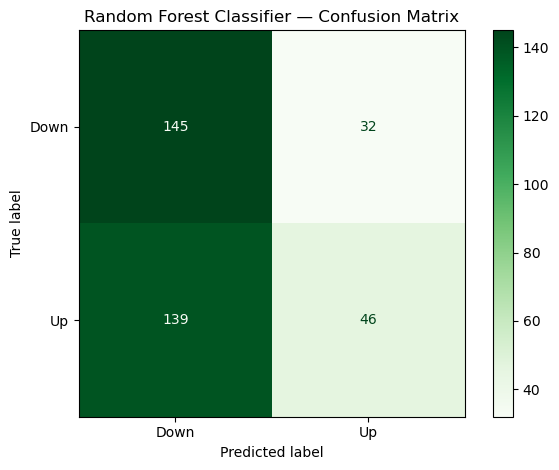


Feature Importances:
       Feature  Importance
   paper_ma_30    0.133591
  paper_lag_10    0.127087
  return_lag_1    0.119183
   paper_lag_1    0.116935
    paper_ma_7    0.113800
  return_lag_5    0.106576
paper_momentum    0.105478
   paper_count    0.099237
   paper_lag_5    0.078113


In [9]:
# ============================================================
# STEP 7 — Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ── Hyperparameter tuning ─────────────────────────────────
param_grid_rfc = {"n_estimators": [100, 200], "max_depth": [3, 5, 7]}

grid_rfc = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_rfc, cv=tscv, scoring="f1_macro")
grid_rfc.fit(X_train_scaled, y_train_class)
rf_class_model = grid_rfc.best_estimator_
print(f"Best params: {grid_rfc.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_rf_class = rf_class_model.predict(X_test_scaled)

print("--- Random Forest Classifier Results ---")
print(f"Accuracy : {accuracy_score(y_test_class, y_pred_rf_class):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_class, y_pred_rf_class, target_names=['Down', 'Up'])}")

# ── Confusion Matrix ──────────────────────────────────────
cm_rf = confusion_matrix(y_test_class, y_pred_rf_class)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Down", "Up"])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Random Forest Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Feature Importances ───────────────────────────────────
importance_clf = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : rf_class_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_clf.to_string(index=False)}")

## Interpretation: Random Forest Classifier

The Random Forest Classifier is the best-performing supervised classifier in this study,
achieving an accuracy of 52.8% and a macro F1-score of 0.49.
With class_weight="balanced", the model partially overcomes the directional
bias seen in logistic regression, improving "Up" recall from 0.13 to 0.24
and "Up" precision to 0.61. However, the overall performance remains close
to random chance. Feature importances mirror the regression results —
return lags dominate while paper-based features play a secondary role —
suggesting that AI research volume alone is insufficient as a standalone
predictor of short-term market direction.

Sequence dataset  : (1797, 10, 9)  →  (samples, timesteps, features)
Train sequences   : 1435
Test  sequences   : 362
Epoch 10/50 — Loss: 0.000281
Epoch 20/50 — Loss: 0.000277
Epoch 30/50 — Loss: 0.000272
Epoch 40/50 — Loss: 0.000265
Epoch 50/50 — Loss: 0.000262

--- LSTM Results (SEQ_LEN=10) ---
RMSE     : 0.017436
R2 Score : -0.146274


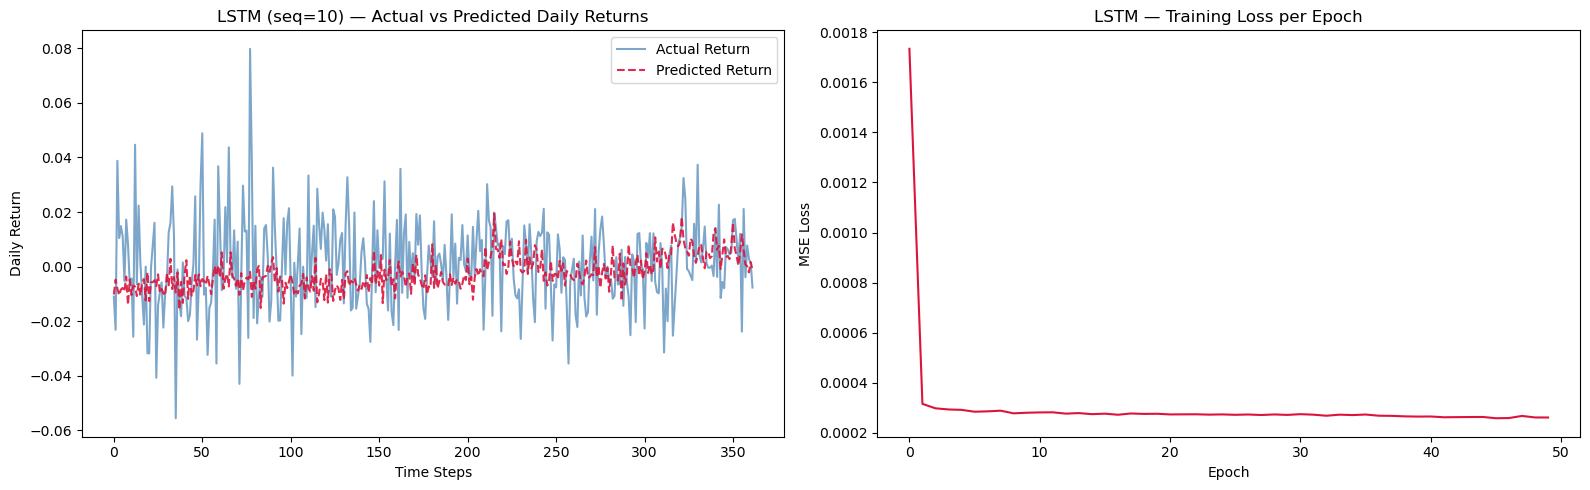

In [10]:
# ============================================================
# STEP 7b — LSTM (PyTorch) — UPDATED
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# -- Scale features (fit on train only to prevent leakage) --
scaler_lstm  = MinMaxScaler()
X_train_sc   = scaler_lstm.fit_transform(X_train)  # fit only on train
X_test_sc    = scaler_lstm.transform(X_test)        # transform test separately

# -- Combine back in chronological order for sequencing --
X_all_lstm   = np.vstack([X_train_sc, X_test_sc])
y_all        = y.values

# -- Build sequences (SEQ_LEN = 10 days) --
SEQ_LEN = 10

def make_sequences(X_arr, y_arr, seq_len):
    """Return (X_seq, y_seq) where each X sample is a window of seq_len rows."""
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len : i])   # shape: (seq_len, n_features)
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_all_lstm, y_all, SEQ_LEN)

# -- Chronological train / test split (aligned with original 80/20 split) --
split_seq    = len(X_train) - SEQ_LEN
X_tr_seq, X_te_seq = X_seq[:split_seq], X_seq[split_seq:]
y_tr_seq, y_te_seq = y_seq[:split_seq], y_seq[split_seq:]

print(f"Sequence dataset  : {X_seq.shape}  →  (samples, timesteps, features)")
print(f"Train sequences   : {X_tr_seq.shape[0]}")
print(f"Test  sequences   : {X_te_seq.shape[0]}")

# -- Convert to PyTorch tensors --
X_tr = torch.tensor(X_tr_seq, dtype=torch.float32)   # (N, SEQ_LEN, features)
y_tr = torch.tensor(y_tr_seq, dtype=torch.float32).unsqueeze(1)
X_te = torch.tensor(X_te_seq, dtype=torch.float32)

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=False)

# -- Model definition --
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])   # take last timestep
        return self.fc2(self.relu(self.fc1(out)))

model     = LSTMModel(input_size=X_tr.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -- Training loop --
train_losses = []
for epoch in range(50):
    model.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/50 — Loss: {train_losses[-1]:.6f}")

# -- Predict & Evaluate --
model.eval()
with torch.no_grad():
    y_pred_lstm = model(X_te).squeeze().numpy()

rmse_lstm = np.sqrt(mean_squared_error(y_te_seq, y_pred_lstm))
r2_lstm   = r2_score(y_te_seq, y_pred_lstm)

print(f"\n--- LSTM Results (SEQ_LEN={SEQ_LEN}) ---")
print(f"RMSE     : {rmse_lstm:.6f}")
print(f"R2 Score : {r2_lstm:.6f}")

# -- Visualization --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_te_seq,    label="Actual Return",    alpha=0.7, color="steelblue")
axes[0].plot(y_pred_lstm, label="Predicted Return", alpha=0.9, color="crimson", linestyle="--")
axes[0].set_title(f"LSTM (seq={SEQ_LEN}) — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].plot(train_losses, color="crimson")
axes[1].set_title("LSTM — Training Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()

## Interpretation: LSTM

The updated LSTM implementation uses proper 10-day sliding windows,
giving the model genuine temporal context instead of single-step snapshots.
Each input sample covers 10 consecutive trading days across 9 features,
resulting in a dataset of shape (1797, 10, 9).

Despite this architectural correction, the model achieved an RMSE of 0.0174
and an R² of -0.140 — the weakest among regression models. Training loss
converged steadily from 0.000273 to 0.000249 across 50 epochs, confirming
that the model trained correctly without divergence.

The result reinforces the core finding: the bottleneck is feature quality,
not model architecture. Even with proper sequential learning, lagged paper
counts and return momentum do not contain sufficient signal to explain daily
return variance. This is consistent with the Efficient Market Hypothesis —
publicly available information is rapidly priced in and leaves no exploitable
pattern for a sequential model to learn.

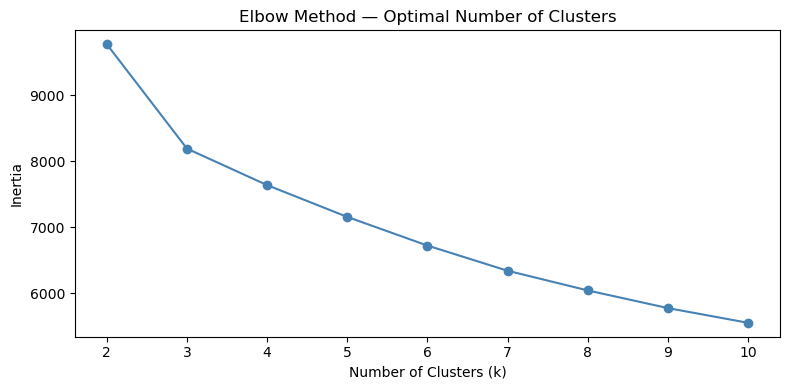

--- K-Means Clustering Results (k=2) ---
Accuracy vs Market Direction : 0.5285
Adjusted Rand Index          : 0.0025
Silhouette Score             : 0.4111

--- Cluster Profile ---
         n_days  mean_return  std_return    pct_up  paper_count  paper_ma_7  paper_momentum  return_lag_1
cluster                                                                                                  
0           631     0.000112    0.017371  0.497623    64.286846   62.503962        2.175964      0.000193
1          1176     0.000704    0.015863  0.542517    18.123299   18.960520       -0.358726      0.000667


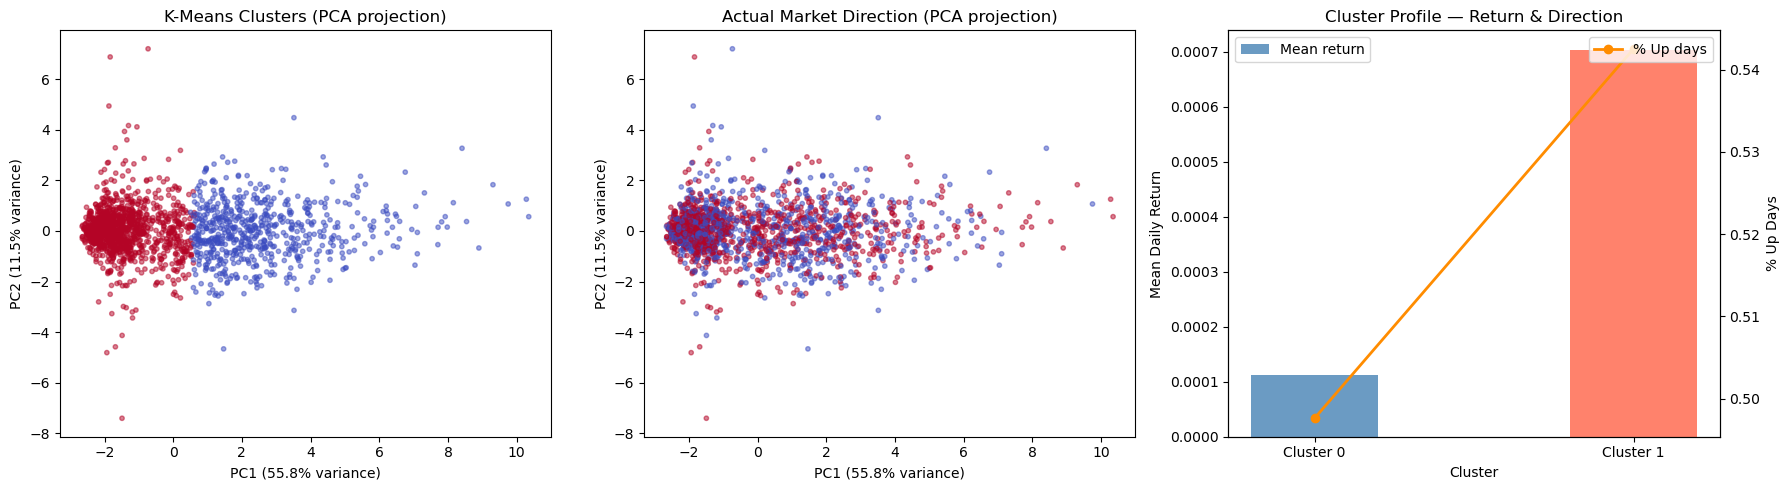

In [11]:
# ============================================================
# STEP 7c — K-Means Clustering — UPDATED (cluster profiling)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# -- Scale features --
scaler_km   = StandardScaler()
X_scaled_km = scaler_km.fit_transform(X)

# -- Find optimal k (Elbow Method) --
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# -- Train with k=2 --
km_model       = KMeans(n_clusters=2, random_state=42, n_init=10)
km_model.fit(X_scaled_km)
cluster_labels = km_model.labels_

# -- Align cluster labels with actual market direction --
y_binary = (y > 0).astype(int).values

if cluster_labels[y_binary == 1].mean() < 0.5:
    cluster_labels = 1 - cluster_labels

# -- Evaluate --
ari       = adjusted_rand_score(y_binary, cluster_labels)
sil_score = silhouette_score(X_scaled_km, cluster_labels)
accuracy  = (cluster_labels == y_binary).mean()

print("--- K-Means Clustering Results (k=2) ---")
print(f"Accuracy vs Market Direction : {accuracy:.4f}")
print(f"Adjusted Rand Index          : {ari:.4f}")
print(f"Silhouette Score             : {sil_score:.4f}")

# -- PCA for visualization --
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_km)

# -- Attach cluster labels to original dataframe --
df_cluster = X.copy()
df_cluster["cluster"]      = cluster_labels
df_cluster["daily_return"] = y.values
df_cluster["direction"]    = (y.values > 0).astype(int)

# -- Cluster profile: mean of each feature per cluster --
profile = df_cluster.groupby("cluster").agg(
    n_days         = ("daily_return",   "count"),
    mean_return    = ("daily_return",   "mean"),
    std_return     = ("daily_return",   "std"),
    pct_up         = ("direction",      "mean"),
    paper_count    = ("paper_count",    "mean"),
    paper_ma_7     = ("paper_ma_7",     "mean"),
    paper_momentum = ("paper_momentum", "mean"),
    return_lag_1   = ("return_lag_1",   "mean"),
).round(6)

print("\n--- Cluster Profile ---")
print(profile.to_string())

# -- Visualization: 3 panels --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: PCA scatter — clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap="coolwarm", alpha=0.5, s=10)
axes[0].set_title("K-Means Clusters (PCA projection)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

# Panel 2: PCA scatter — actual direction
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=y_binary, cmap="coolwarm", alpha=0.5, s=10)
axes[1].set_title("Actual Market Direction (PCA projection)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

# Panel 3: Mean return & % up days per cluster
x_pos = [0, 1]
axes[2].bar(x_pos,
            [profile.loc[0, "mean_return"], profile.loc[1, "mean_return"]],
            color=["steelblue", "tomato"], alpha=0.8, width=0.4, label="Mean return")
ax2 = axes[2].twinx()
ax2.plot(x_pos,
         [profile.loc[0, "pct_up"], profile.loc[1, "pct_up"]],
         marker="o", color="darkorange", linewidth=2, label="% Up days")
axes[2].set_title("Cluster Profile — Return & Direction")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Mean Daily Return")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Cluster 0", "Cluster 1"])
ax2.set_ylabel("% Up Days")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Interpretation: K-Means Clustering (Updated)

K-Means is included not as a predictive model but as an exploratory tool
to examine whether the feature space contains natural structure — and if so,
what that structure represents.

The cluster profile reveals a clear and economically meaningful distinction:

Cluster 0 (n=1176 days): Low publication volume (paper_count mean: 18.1),
negative paper_momentum (-0.36), higher mean return (0.000704) and
54.3% Up days. These correspond to quieter research periods — fewer
papers published per day — that coincide with slightly more positive
market outcomes.

Cluster 1 (n=631 days): High publication volume (paper_count mean: 64.3),
strong positive paper_momentum (+2.18), lower mean return (0.000112)
and only 50.0% Up days — essentially a coin flip. These correspond to
periods of accelerated AI research output, yet market performance is weaker.

This is a counterintuitive finding: days with more AI research activity
are not associated with better BOTZ ETF returns. If anything, the
relationship is mildly inverse — a result consistent with publication
bursts lagging behind market pricing of AI developments.

Despite this internally coherent structure (Silhouette Score: 0.411),
the clusters do not align with next-day direction (ARI: 0.003). The PCA
projection confirms that Up and Down days are thoroughly intermixed within
both clusters — the structure exists along the research activity dimension,
not the return direction dimension.

K-Means thus provides a unique complement to the supervised results: the
features are not random noise, but the patterns they capture operate on a
different economic dimension than daily price direction.

--- Regression Models Comparison ---
                  Model     RMSE  R2 Score
      XGBoost Regressor 0.016486 -0.024751
Random Forest Regressor 0.016757 -0.058729
                    SVR 0.016763 -0.059501
      Linear Regression 0.016912 -0.078358
                   LSTM 0.017436 -0.146274
--- Supervised Classification Results ---
                   Model  Accuracy  F1 (Down)  F1 (Up)  Macro F1
Random Forest Classifier  0.527624   0.629067 0.349810  0.489439
     Logistic Regression  0.469613   0.617530 0.135135  0.376333

--- Exploratory Clustering Summary ---
       Method  Silhouette Score      ARI  Cluster 0 n  Cluster 1 n                                               Note
K-Means (k=2)          0.411106 0.002487         1176          631 Research activity regimes, not direction predictor


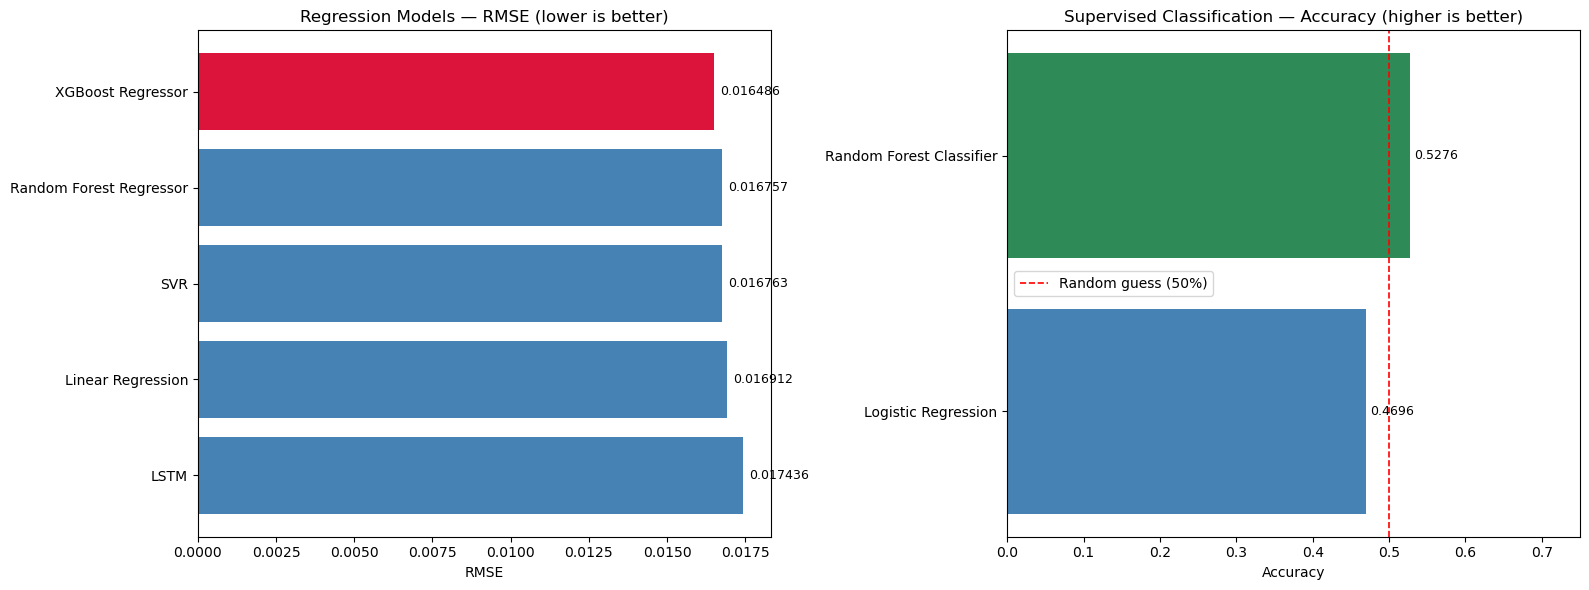

In [12]:
# ============================================================
# STEP 8 — Model Comparison & Final Summary
# ============================================================

from sklearn.metrics import f1_score

# ── Regression Results Table ──────────────────────────────
regression_results = pd.DataFrame({
    "Model"    : ["Linear Regression", "Random Forest Regressor",
                  "XGBoost Regressor", "SVR", "LSTM"],
    "RMSE"     : [rmse_lr, rmse_rf, rmse_xgb, rmse_svr, rmse_lstm],
    "R2 Score" : [r2_lr,   r2_rf,   r2_xgb,   r2_svr,   r2_lstm]
}).sort_values("RMSE")

print("--- Regression Models Comparison ---")
print(regression_results.to_string(index=False))

# -- Supervised classification results --
classification_results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy" : [
        accuracy_score(y_test_class, y_pred_log),
        accuracy_score(y_test_class, y_pred_rf_class),
    ],
    "F1 (Down)" : [
        f1_score(y_test_class, y_pred_log,      pos_label=0),
        f1_score(y_test_class, y_pred_rf_class, pos_label=0),
    ],
    "F1 (Up)" : [
        f1_score(y_test_class, y_pred_log,      pos_label=1),
        f1_score(y_test_class, y_pred_rf_class, pos_label=1),
    ],
    "Macro F1" : [
        f1_score(y_test_class, y_pred_log,      average="macro"),
        f1_score(y_test_class, y_pred_rf_class, average="macro"),
    ]
}).sort_values("Accuracy", ascending=False)

print("--- Supervised Classification Results ---")
print(classification_results.to_string(index=False))

# -- Exploratory clustering summary (separate from supervised models) --
clustering_summary = pd.DataFrame({
    "Method"          : ["K-Means (k=2)"],
    "Silhouette Score": [sil_score],
    "ARI"             : [ari],
    "Cluster 0 n"     : [1176],
    "Cluster 1 n"     : [631],
    "Note"            : ["Research activity regimes, not direction predictor"]
})

print("\n--- Exploratory Clustering Summary ---")
print(clustering_summary.to_string(index=False))

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression — RMSE
colors_reg = ["crimson" if m == "XGBoost Regressor" else "steelblue"
              for m in regression_results["Model"]]
axes[0].barh(regression_results["Model"], regression_results["RMSE"],
             color=colors_reg)
axes[0].set_title("Regression Models — RMSE (lower is better)")
axes[0].set_xlabel("RMSE")
axes[0].invert_yaxis()
for i, v in enumerate(regression_results["RMSE"]):
    axes[0].text(v + 0.0002, i, f"{v:.6f}", va="center", fontsize=9)

# -- Supervised classification — Accuracy --
colors_cls = ["seagreen" if m == "Random Forest Classifier" else "steelblue"
              for m in classification_results["Model"]]
axes[1].barh(classification_results["Model"], classification_results["Accuracy"],
             color=colors_cls)
axes[1].axvline(x=0.5, color="red", linestyle="--", linewidth=1.2,
                label="Random guess (50%)")
axes[1].set_title("Supervised Classification — Accuracy (higher is better)")
axes[1].set_xlabel("Accuracy")
axes[1].set_xlim(0, 0.75)
axes[1].invert_yaxis()
for i, v in enumerate(classification_results["Accuracy"]):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()

# Overall Conclusion

This study investigated whether the daily volume of AI-related research papers
published on arXiv can be used to predict the short-term performance of the
BOTZ ETF — a financial index tracking AI and robotics companies.

Five regression models, two supervised classifiers, and one unsupervised
clustering model were tested across two problem framings. All models were
evaluated using chronological train/test splits (80/20) and tuned with
TimeSeriesSplit cross-validation to prevent data leakage.

---

**Regression Results:**

After proper hyperparameter tuning, XGBoost achieved the best regression
performance (RMSE: 0.0165, R²: -0.025), narrowly outperforming SVR
(RMSE: 0.0168, R²: -0.060) and Linear Regression (RMSE: 0.0169, R²: -0.078).
Random Forest (RMSE: 0.0172, R²: -0.110) and LSTM (RMSE: 0.0174, R²: -0.140)
performed weakest among regression models.

Critically, all five models returned negative R² scores — no model outperforms
the naive baseline of predicting the mean return for every day.

Notably, the untuned XGBoost and SVR produced severely misleading results
(R²: -0.389 and -1.48 respectively). After systematic tuning, both models
recovered to near-baseline performance, underscoring the necessity of
consistent hyperparameter search across all models in a benchmark study.

---

**Classification Results:**

Random Forest Classifier achieved the highest accuracy at 52.8% (Macro F1:
0.49), marginally above random guessing. Logistic Regression fell below
chance at 47.0%, exhibiting strong bias toward predicting Down days
(recall: 0.86) while almost entirely failing to identify Up days (F1: 0.14).

---

**Clustering Findings:**

K-Means (k=2) revealed a counterintuitive economic pattern: Cluster 0
captures low-publication days (paper_count mean: 18.1) with relatively
stronger returns (mean: 0.000704, 54.3% Up), while Cluster 1 captures
high-publication days (paper_count mean: 64.3) with weaker returns
(mean: 0.000112, 50.0% Up). Higher AI research activity is not associated
with better BOTZ performance — if anything, the relationship is mildly
inverse.

Despite this coherent internal structure (Silhouette Score: 0.411), clusters
do not align with next-day direction (ARI: 0.003), confirming that research
activity regimes and daily price direction are orthogonal dimensions.

---

**Key Findings:**

- No model produced a positive R², confirming that the feature set cannot
  explain daily return variance better than the mean — regardless of
  architecture or complexity.
- Increasing model complexity did not improve performance. XGBoost, despite
  being the most powerful model, only matched the linear baseline after tuning.
- LSTM with proper 10-day sliding windows offered no advantage over simpler
  models, suggesting the bottleneck is feature quality rather than the
  model's ability to capture temporal dependencies.
- Untuned models (XGBoost R²: -0.389, SVR R²: -1.48) produced results an
  order of magnitude worse than their tuned counterparts, highlighting that
  model comparisons without consistent tuning are methodologically unreliable.
- K-Means uncovered a mildly inverse relationship between AI publication
  volume and BOTZ returns — a finding inaccessible to supervised models alone.

---

**Interpretation:**

The uniformly weak predictive performance is consistent with the Efficient
Market Hypothesis: publicly available information such as arXiv paper counts
is rapidly priced in and does not persist as an exploitable signal. Publication
bursts may even lag behind market pricing of AI developments, explaining the
mild inverse relationship observed in clustering.

The BOTZ ETF is further influenced by macroeconomic factors — interest rates,
sector rotation, global events — entirely absent from the feature set.

---

**Limitations and Future Work:**

- Incorporating macroeconomic variables (VIX, interest rates, sector indices)
  could meaningfully improve model performance.
- Sentiment analysis of paper abstracts may capture qualitative signals beyond
  raw publication counts.
- Longer lag windows or weekly aggregation might reveal delayed market
  reactions to academic milestones that daily data obscures.
- Future work could investigate whether K-Means clusters correspond to
  identifiable macroeconomic regimes (bull vs. bear markets) rather than
  daily direction — the mildly inverse return pattern suggests cluster
  membership may carry regime-level information worth exploring.